In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
def projection(density_mat):
    """
    Returns the 2D projection of a 3D density matrix along the z-axis.

    Parameters:
    - density_mat (numpy.ndarray): The 3D density matrix representing the density distribution.
                                   The shape of the matrix should be (M, N, K), where M, N, and K
                                   are the dimensions along the x, y, and z axes respectively.

    Returns:
    float or array-like: Projected Density value(s) along the z-axis.

    This function calculates the projection of the given density matrix along the z-axis,
    summing up the values along the z-axis to produce a 2D array. 
    """
    projection_z_axis = np.sum(density_mat, axis = 2)
    return projection_z_axis

In [3]:
def plot_img_logscale(proj_density_mat):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                   

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat, norm=colors.LogNorm(vmin=proj_density_mat.min(), vmax=proj_density_mat.max()), origin='lower',cmap = 'plasma')
    plt.colorbar(label='Color Scale (log)')
    plt.axis('off')
    plt.show()
 

In [4]:
def rho(x,y,z,e,p,q,rho0,s,a,b):
    """
    Calculate density value based on input coordinates and parameters.

    Parameters:
    x (float or array-like): x-coordinate(s) of the point(s).
    y (float or array-like): y-coordinate(s) of the point(s).
    z (float or array-like): z-coordinate(s) of the point(s).
    e (float): Parameter describing the disky/boxiness of the triaxial body.
    p (float): Axis ratio b/a.
    q (float): Axis ratio c/a.
    rho0 (float): Normalization parameter for density.
    s (float): Scale radius.
    a (float): Power-law exponent.
    b (float): Power-law exponent.

    Returns:
    float or array-like: Density value(s) at the given coordinates.

    Formula:
    The function calculates density value(s) based on the input coordinates (x, y, z) and parameters (e, p, q, rho0, s, a, b)
    using the following formula:

        r = ((|x|^(2 - e) + (|y| / p)^(2 - e) + (|z| / q)^(2 - e)))^(1/(2-e))
        rho = rho0 / ((r / s)^a * (1 + (r / s))^(b - a))

    where:
        |x|, |y|, |z|: Absolute values of the coordinates.
        e: Exponent parameter.
        p, q: Scaling parameters for x and y coordinates.
        rho0: Normalization parameter for density.
        s: Scaling parameter for distance.
        a, b: Shape parameters.
        r: Distance metric calculated based on the input coordinates.
        rho: Density value calculated based on the input parameters and coordinates.
    """
    r = ((np.abs(x)**(2 - e) + (np.abs(y) / p)**(2 - e) + (np.abs(z) / q)**(2 - e)))**(1/(2-e))
    den = rho0 / ((r/s)**a*(1+(r/s))**(b-a))
    #den = np.round(den, decimals=6)
    return den

In [5]:
def projection_matrix(phi,theta):
    """
    Compute the projection matrix based on the angles phi and theta.
    
    Parameters:
    phi (float): Phi represents a clock-wise rotation in the y-z plane in radians.
    theta (float): Theta represents a counter-clock-wise rotation in the x-y-plane in radians.

    Returns:
    numpy.ndarray: Projection matrix for the given angles.

    Formula:
    The function calculates the projection matrix (P) based on the given phi and theta angles.
    The projection matrix P is defined as follows:

        P = | -sin(phi)        cos(phi)          0 |
            | -cos(phi)*cos(theta)  -sin(phi)*cos(theta)  sin(theta) |
            |  cos(phi)*sin(theta)   sin(phi)*sin(theta)  cos(theta) |

    where:
        phi: Represents a clock-wise rotation in the y-z plane in radians.
        theta: Represents a counter-clock-wise rotation in the x-y-plane in radians.
        P: Projection matrix.

    """
    P = np.array([[-np.sin(phi), np.cos(phi), 0],
             [-np.cos(phi)*np.cos(theta), -np.sin(phi)*np.cos(theta), np.sin(theta)],
             [np.cos(phi)*np.sin(theta), np.sin(phi)*np.sin(theta), np.cos(theta)]])
    return P
    

def psi_rotation_matrix(psi):
    """
    Compute the rotation matrix around the z-axis.

    Parameters:
    psi (float): Represents a counter-clock-wise rotaion around the z'-axis in radians.

    Returns:
    numpy.ndarray: Rotation matrix for the given angle.

    Formula:
    The function calculates the rotation matrix (R_psi) for the given rotation angle psi around the z'-axis.
    The rotation matrix R_psi is defined as follows:

        R_psi = |  sin(psi)  -cos(psi)  0 |
                |  cos(psi)   sin(psi)  0 |
                |  0           0         1 |

    where:
        psi: Represents a counter-clock-wise rotaion around the z'-axis in radians.
        R_psi: Rotation matrix.

    """
    R_psi = np.array([[np.sin(psi), -np.cos(psi), 0],
                        [np.cos(psi), np.sin(psi), 0],
                        [0, 0, 1]])
    return R_psi

def rotation_intrisic_to_skyplane(pos_ar,phi,theta,psi):
    
    """
    Rotate position vectors from the intrinsic coordinate system on the sky plane to the coordinate system on the sky plane.

    Parameters:
    pos_ar (numpy.ndarray): Array of position vectors to be rotated, of the form [[x1,y1,z1],.....,[xn,yn,zn]].
    phi (float): Phi represents a clock-wise rotation in the y-z plane in degrees.
    theta (float): Theta represents a counter-clock-wise rotation in the x-y-plane in degrees.
    psi (float): Represents a counter-clock-wise rotaion around the z'-axis in degrees.

    Returns:
    numpy.ndarray: Array of rotated position vectors.

    Formula:
    The function rotates the position vectors from the sky plane to the intrinsic plane using the following steps:
    1. Convert the input angles from degrees to radians.
    2. Compute the projection matrix (P) based on the phi and theta angles.
    3. Compute the rotation matrix (R_psi) around the z'-axis using the psy angle.
    4. Rotate the position vectors using matrix multiplication as follows:
        rot_pos_ar = R_psi @ P @ pos_ar^T
    5. Return the transposed result to get the array of rotated position vectors in the shape that was originally provided.

    where:
        pos_ar: Array of position vectors to be rotated.
        phi: Clock-wise rotation in the y-z plane in degrees.
        theta: Counter-clock-wise rotation in the x-y-plane in degrees.
        psi: Counter-clock-wise rotation angle around the z'-axis in degrees.
        P: Projection matrix.
        R_psi: Rotation matrix around the z'-axis.
        rot_pos_ar: Rotated position vectors.

    """
    phi = np.radians(phi)
    theta = np.radians(theta)
    psi = np.radians(psi)
    
    P = projection_matrix(phi,theta)
    R_psi = psi_rotation_matrix(psi)
    
    rot_pos_ar = R_psi@P@pos_ar.T

    rot_pos_ar = np.round(rot_pos_ar, decimals=10)

    return rot_pos_ar.T


def rotation_skyplane_to_intrinsic(pos_ar,phi,theta,psi):
    """
    Rotate position vectors from the coordinate system on the sky plane to the intrinsic coordinate system.

    Parameters:
    pos_ar (numpy.ndarray): Array of position vectors to be rotated, of the form [[x1,y1,z1],.....,[xn,yn,zn]].
    phi (float): Phi represents a clock-wise rotation in the y-z plane in degrees.
    theta (float): Theta represents a counter-clock-wise rotation in the x-y-plane in degrees.
    psi (float): Represents a counter-clock-wise rotaion around the z'-axis in degrees.

    Returns:
    numpy.ndarray: Array of rotated position vectors.

    Formula:
    The function rotates the position vectors from the sky plane to the intrinsic plane using the following steps:
    1. Convert the input angles from degrees to radians.
    2. Compute the projection matrix (P) based on the phi and theta angles.
    3. Compute the rotation matrix (R_psi) around the z'-axis using the psy angle.
    4. Rotate the position vectors using matrix multiplication as follows:
        rot_pos_ar = P^T @ R_psi^T @ pos_ar^T
    5. Return the transposed result to get the array of rotated position vectors in the shape that was originally provided.

    where:
        pos_ar: Array of position vectors to be rotated.
        phi: Clock-wise rotation in the y-z plane in degrees.
        theta: Counter-clock-wise rotation in the x-y-plane in degrees.
        psi: Counter-clock-wise rotation angle around the z'-axis in degrees.
        P: Projection matrix.
        R_psi: Rotation matrix around the z'-axis.
        rot_pos_ar: Rotated position vectors.

    """
    
    phi = np.radians(phi)
    theta = np.radians(theta)
    psi = np.radians(psi)
    
    P = projection_matrix(phi,theta)
    R_psi = psi_rotation_matrix(psi)
    
    rot_pos_ar = P.T@R_psi.T@pos_ar.T

    rot_pos_ar = np.round(rot_pos_ar, decimals=10)

    return rot_pos_ar.T


In [6]:
s = 1 
e = 0
p = 0.8
q = 0.6
a = 2
b = 4
rho0 = 0.001


# Define the size of your 3D matrix
x_size, y_size, z_size = 50, 50, 50

# Create 3D coordinates
x, y, z = np.meshgrid(np.linspace(-0.01, 0.01, x_size),
                      np.linspace(-0.01, 0.01, y_size),
                      np.linspace(-0.01, 0.01, z_size))

x = np.round(x, decimals=10)
y = np.round(y, decimals=10)
z = np.round(z, decimals=10)


pos_ar = np.array([x.flatten(),y.flatten(),z.flatten()])
density_1st = rho(x.flatten(),y.flatten(),z.flatten(),e,p,q,rho0,s,a,b)
density_1st = density_1st.reshape((50,50,50))
proj_density_1st = projection(density_1st)

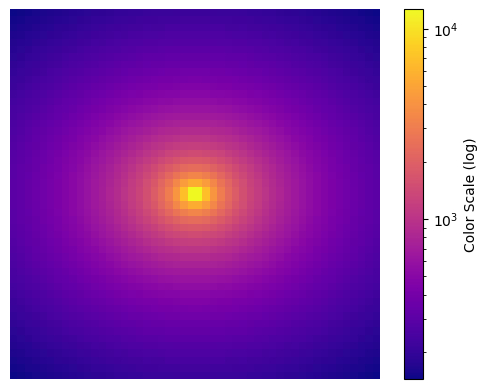

In [7]:
plot_img_logscale(proj_density_1st)

In [8]:
rot_test_big = rotation_intrisic_to_skyplane(pos_ar.T,7,254,69)
rot_test_big

array([[-0.01047251,  0.0029862 ,  0.01346882],
       [-0.0103319 ,  0.00261991,  0.01335632],
       [-0.01019129,  0.00225362,  0.01324381],
       ...,
       [ 0.01019129, -0.00225362, -0.01324381],
       [ 0.0103319 , -0.00261991, -0.01335632],
       [ 0.01047251, -0.0029862 , -0.01346882]])

In [9]:
back_rot_test_big = rotation_skyplane_to_intrinsic(rot_test_big,7,254,69)
back_rot_test_big

array([[-0.01      , -0.01      , -0.01      ],
       [-0.01      , -0.01      , -0.00959184],
       [-0.01      , -0.01      , -0.00918367],
       ...,
       [ 0.01      ,  0.01      ,  0.00918367],
       [ 0.01      ,  0.01      ,  0.00959184],
       [ 0.01      ,  0.01      ,  0.01      ]])

In [10]:
pos_ar.T

array([[-0.01      , -0.01      , -0.01      ],
       [-0.01      , -0.01      , -0.00959184],
       [-0.01      , -0.01      , -0.00918367],
       ...,
       [ 0.01      ,  0.01      ,  0.00918367],
       [ 0.01      ,  0.01      ,  0.00959184],
       [ 0.01      ,  0.01      ,  0.01      ]])

In [11]:
comparison = back_rot_test_big == pos_ar.T
np.all(comparison)

False

In [12]:
# Find indices where elements are different
indices_different = np.where(back_rot_test_big != pos_ar.T)

# Get the values of the elements that are different
values_different = back_rot_test_big[indices_different]
values_different

array([-0.01      , -0.00714286, -0.00142857, ...,  0.00142857,
        0.00714286,  0.01      ])

In [13]:
values_different1 = pos_ar.T[indices_different]
values_different1

array([-0.01      , -0.00714286, -0.00142857, ...,  0.00142857,
        0.00714286,  0.01      ])

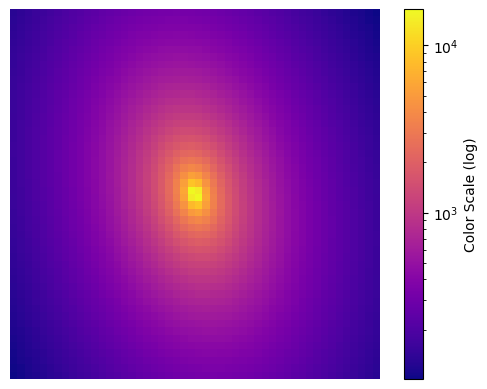

In [14]:
den_1_rot = rho(rot_test_big[:,0], rot_test_big[:,1], rot_test_big[:,2],e,p,q,rho0,s,a,b)
den_1_rot = den_1_rot.reshape((50,50,50))
proj_density_1_rot = projection(den_1_rot)
plot_img_logscale(proj_density_1_rot)

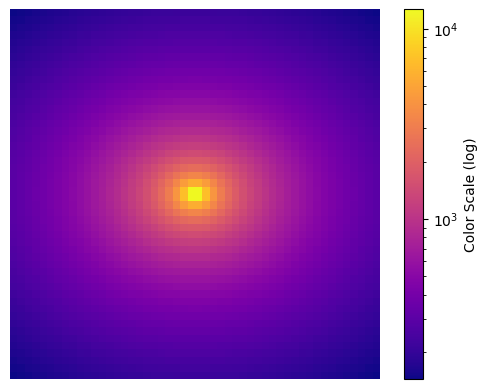

In [15]:
den_2_rot = rho(back_rot_test_big[:,0], back_rot_test_big[:,1], back_rot_test_big[:,2],e,p,q,rho0,s,a,b)
den_2_rot = den_2_rot.reshape((50,50,50))
proj_density_2_rot = projection(den_2_rot)
plot_img_logscale(proj_density_2_rot)

In [16]:
def ssd(image1, image2):
    """
    Compute Sum of Squared Differences (SSD) between two images.
    
    Args:
    - image1: numpy array representing the first image
    - image2: numpy array representing the second image
    
    Returns:
    - ssd_value: sum of squared differences between the two images
    """
    # Ensure images have the same shape
    if image1.shape != image2.shape:
        raise ValueError("Images must have the same dimensions")
    
    # Calculate SSD
    ssd_value = np.sum((image1 - image2)**2)
    
    return ssd_value

In [17]:
ssd(proj_density_1st,proj_density_2_rot)

1.0958406153455338e-05

In [18]:
ssd(proj_density_1st,proj_density_1_rot)

173785413.04080507